In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scienceplots
import pytorch_lightning as pl

torch.manual_seed(67)
np.random.seed(67)
sns.set_palette("husl")
# importing my preferred style
plt.style.use(['science', 'no-latex', 'grid'])
plt.rcParams.update({'font.size':20})
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams['axes.formatter.use_mathtext'] = True

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

print(f"Is CUDA supported by this system? {torch.cuda.is_available()}")
print(f"Current CUDA device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"CUDA version: {torch.version.cuda}")
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

Using cuda device
Is CUDA supported by this system? True
Current CUDA device name: NVIDIA GeForce RTX 3090
CUDA version: 13.0


In [ ]:
from datasets import load_dataset

c:\Users\danib\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Augmented dataset with bbox-aware transforms
import random
import torch
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

IMG_SIZE = 224
RESIZE_SIZE = 232


def _scale_bbox(box, orig_w, orig_h, new_w=224, new_h=224):
    x_min, y_min, x_max, y_max = box
    sx = new_w / orig_w
    sy = new_h / orig_h
    return [x_min * sx, y_min * sy, x_max * sx, y_max * sy]


# Color-only augmentation (safe for bbox)
_color_jitter = transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)
_auto_contrast = transforms.RandomAutocontrast(p=0.2)
_equalize = transforms.RandomEqualize(p=0.1)
_sharpness = transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.2)


def _apply_color_aug(img):
    img = _color_jitter(img)
    img = _auto_contrast(img)
    img = _equalize(img)
    img = _sharpness(img)
    return img


def _bbox_safe_random_erase(img_tensor, bbox, p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), max_tries=10):
    if random.random() > p:
        return img_tensor
    _, h, w = img_tensor.shape
    x_min, y_min, x_max, y_max = bbox
    area = h * w
    for _ in range(max_tries):
        target_area = random.uniform(*scale) * area
        aspect_ratio = random.uniform(*ratio)
        erase_h = int(round((target_area * aspect_ratio) ** 0.5))
        erase_w = int(round((target_area / aspect_ratio) ** 0.5))
        if erase_h < h and erase_w < w:
            top = random.randint(0, h - erase_h)
            left = random.randint(0, w - erase_w)
            no_overlap = (left + erase_w <= x_min or left >= x_max or top + erase_h <= y_min or top >= y_max)
            if no_overlap:
                img_tensor[:, top:top + erase_h, left:left + erase_w] = torch.randn(
                    img_tensor.size(0), erase_h, erase_w, device=img_tensor.device
                ) * 0.1
                return img_tensor
    return img_tensor


def _apply_train_transform(img, bbox):
    # Resize to slightly larger then random crop (mild scale jitter)
    orig_w, orig_h = img.size
    img = TF.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    bbox = _scale_bbox(bbox, orig_w, orig_h, RESIZE_SIZE, RESIZE_SIZE)

    # Random crop to target size (milder than before)
    i, j, h, w = transforms.RandomCrop.get_params(img, output_size=(IMG_SIZE, IMG_SIZE))
    img = TF.crop(img, i, j, h, w)

    # Adjust bbox for crop
    bbox = [
        bbox[0] - j,
        bbox[1] - i,
        bbox[2] - j,
        bbox[3] - i,
    ]
    bbox = [max(0, min(IMG_SIZE, b)) for b in bbox]

    # Random horizontal flip with bbox update
    if random.random() < 0.5:
        img = TF.hflip(img)
        x_min, y_min, x_max, y_max = bbox
        bbox = [IMG_SIZE - x_max, y_min, IMG_SIZE - x_min, y_max]

    # Color-only augmentation (bbox-safe)
    img = _apply_color_aug(img)

    # To tensor + normalize
    img = TF.to_tensor(img)
    img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # BBox-safe random erasing
    img = _bbox_safe_random_erase(img, bbox)

    # Normalize bbox to [0,1]
    bbox = [b / IMG_SIZE for b in bbox]
    return img, bbox


def _apply_eval_transform(img, bbox):
    orig_w, orig_h = img.size
    img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
    bbox = _scale_bbox(bbox, orig_w, orig_h, IMG_SIZE, IMG_SIZE)
    img = TF.to_tensor(img)
    img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    bbox = [b / IMG_SIZE for b in bbox]
    return img, bbox


def _transform_split(example, train=True):
    imgs = example['img']
    bboxes = example.get('bbox')
    if isinstance(imgs, list):
        new_imgs = []
        new_boxes = []
        for i, img in enumerate(imgs):
            if train:
                img_t, box_t = _apply_train_transform(img, bboxes[i])
            else:
                img_t, box_t = _apply_eval_transform(img, bboxes[i])
            new_imgs.append(img_t)
            new_boxes.append(box_t)
        example['img'] = new_imgs
        example['bbox'] = new_boxes
    else:
        if train:
            img_t, box_t = _apply_train_transform(imgs, bboxes)
        else:
            img_t, box_t = _apply_eval_transform(imgs, bboxes)
        example['img'] = img_t
        example['bbox'] = box_t
    return example


def transform_train(example):
    return _transform_split(example, train=True)


def transform_eval(example):
    return _transform_split(example, train=False)


# Load dataset and apply transforms
_ds = load_dataset("cvdl/oxford-pets")

# Keep only needed columns to avoid PIL collate errors
keep_cols = {'img', 'bbox', 'category'}
for split_name in ['train', 'valid', 'test']:
    cols = list(_ds[split_name].column_names)
    drop_cols = [c for c in cols if c not in keep_cols]
    if drop_cols:
        _ds[split_name] = _ds[split_name].remove_columns(drop_cols)

train_ds = _ds['train'].with_transform(transform_train)
valid_ds = _ds['valid'].with_transform(transform_eval)
test_ds = _ds['test'].with_transform(transform_eval)

train_loader_aug = DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader_aug = DataLoader(valid_ds, batch_size=64, shuffle=False)
test_loader_aug = DataLoader(test_ds, batch_size=64, shuffle=False)

print("✓ Augmentation enabled (mild crop + flip + color-only aug + bbox-safe erasing)")
print("  Batch size: 64")

✓ Augmentation enabled (mild crop + flip + light color jitter)
  Batch size: 64


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import torchmetrics
from torchvision.ops import box_iou, generalized_box_iou


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, se_reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels, reduction=se_reduction)
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += identity
        return F.relu(out)


class MaxPerformanceCNN(pl.LightningModule):
    def __init__(self, num_classes=37, lr=3e-4, bbox_loss_weight=1.5, giou_weight=0.2, label_smoothing=0.0):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.bbox_loss_weight = bbox_loss_weight
        self.giou_weight = giou_weight
        self.label_smoothing = label_smoothing

        self.stage1 = self._make_stage(3, 64, num_blocks=2, stride=2)
        self.stage2 = self._make_stage(64, 128, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(128, 256, num_blocks=2, stride=2)
        self.stage4 = self._make_stage(256, 512, num_blocks=2, stride=2)
        self.stage5 = self._make_stage(512, 512, num_blocks=2, stride=2)

        self.class_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        self.bbox_conv = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.bbox_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.bbox_regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.Sigmoid()
        )

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        layers = [ResidualBlock(in_channels, out_channels, stride=stride)]
        for _ in range(num_blocks - 1):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)

        class_logits = self.classifier(self.class_pool(x))
        bbox_features = self.bbox_pool(self.bbox_conv(x))
        bbox_coords = self.bbox_regressor(bbox_features)
        return class_logits, bbox_coords

    def _unpack_batch(self, batch):
        if isinstance(batch, dict):
            images = batch["img"]
            labels = batch["category"]
            target_bboxes = batch.get("bbox")
        else:
            images, labels, target_bboxes = batch

        if torch.is_tensor(target_bboxes):
            target_bboxes = target_bboxes.float()
        elif isinstance(target_bboxes, (list, tuple)) and len(target_bboxes) > 0:
            if torch.is_tensor(target_bboxes[0]):
                target_bboxes = torch.stack(target_bboxes, dim=0).float()
            else:
                target_bboxes = torch.tensor(target_bboxes, device=images.device, dtype=torch.float32)
        else:
            target_bboxes = torch.tensor(target_bboxes, device=images.device, dtype=torch.float32)

        if target_bboxes.ndim == 1:
            target_bboxes = target_bboxes.unsqueeze(0)
        if target_bboxes.ndim == 2 and target_bboxes.shape[0] == 4:
            target_bboxes = target_bboxes.transpose(0, 1)

        return images, labels.long(), target_bboxes

    def _compute_giou_loss(self, pred_boxes, target_boxes):
        pred_boxes_scaled = pred_boxes * IMG_SIZE
        target_boxes_scaled = target_boxes * IMG_SIZE

        pred_boxes_scaled = torch.stack([
            torch.min(pred_boxes_scaled[:, 0], pred_boxes_scaled[:, 2]),
            torch.min(pred_boxes_scaled[:, 1], pred_boxes_scaled[:, 3]),
            torch.max(pred_boxes_scaled[:, 0], pred_boxes_scaled[:, 2]),
            torch.max(pred_boxes_scaled[:, 1], pred_boxes_scaled[:, 3])
        ], dim=1)

        target_boxes_scaled = torch.stack([
            torch.min(target_boxes_scaled[:, 0], target_boxes_scaled[:, 2]),
            torch.min(target_boxes_scaled[:, 1], target_boxes_scaled[:, 3]),
            torch.max(target_boxes_scaled[:, 0], target_boxes_scaled[:, 2]),
            torch.max(target_boxes_scaled[:, 1], target_boxes_scaled[:, 3])
        ], dim=1)

        giou_matrix = generalized_box_iou(pred_boxes_scaled, target_boxes_scaled)
        giou = torch.diag(giou_matrix).mean()
        return 1 - giou

    def _compute_iou(self, pred_boxes, target_boxes):
        pred_boxes_scaled = pred_boxes * IMG_SIZE
        target_boxes_scaled = target_boxes * IMG_SIZE

        pred_boxes_scaled = torch.stack([
            torch.min(pred_boxes_scaled[:, 0], pred_boxes_scaled[:, 2]),
            torch.min(pred_boxes_scaled[:, 1], pred_boxes_scaled[:, 3]),
            torch.max(pred_boxes_scaled[:, 0], pred_boxes_scaled[:, 2]),
            torch.max(pred_boxes_scaled[:, 1], pred_boxes_scaled[:, 3])
        ], dim=1)

        target_boxes_scaled = torch.stack([
            torch.min(target_boxes_scaled[:, 0], target_boxes_scaled[:, 2]),
            torch.min(target_boxes_scaled[:, 1], target_boxes_scaled[:, 3]),
            torch.max(target_boxes_scaled[:, 0], target_boxes_scaled[:, 2]),
            torch.max(target_boxes_scaled[:, 1], target_boxes_scaled[:, 3])
        ], dim=1)

        iou_matrix = box_iou(pred_boxes_scaled, target_boxes_scaled)
        return torch.diag(iou_matrix).mean()

    def _shared_step(self, batch):
        images, labels, target_bboxes = self._unpack_batch(batch)
        pred_logits, pred_bboxes = self(images)

        loss_class = F.cross_entropy(pred_logits, labels, label_smoothing=self.label_smoothing)
        loss_giou = self._compute_giou_loss(pred_bboxes, target_bboxes)
        loss_l1 = F.smooth_l1_loss(pred_bboxes, target_bboxes)
        loss_bbox = self.giou_weight * loss_giou + (1 - self.giou_weight) * loss_l1
        total_loss = loss_class + self.bbox_loss_weight * loss_bbox

        with torch.no_grad():
            iou = self._compute_iou(pred_bboxes, target_bboxes)

        preds = torch.argmax(pred_logits, dim=1)
        return total_loss, loss_class, loss_bbox, iou, preds, labels

    def training_step(self, batch, batch_idx):
        total_loss, loss_class, loss_bbox, iou, preds, labels = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log('train_loss', total_loss, on_epoch=True, prog_bar=True)
        self.log('train_class_loss', loss_class, on_epoch=True)
        self.log('train_bbox_loss', loss_bbox, on_epoch=True)
        self.log('train_iou', iou, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_epoch=True, prog_bar=True)
        return total_loss

    def validation_step(self, batch, batch_idx):
        total_loss, loss_class, loss_bbox, iou, preds, labels = self._shared_step(batch)
        self.val_acc(preds, labels)
        self.log('val_loss', total_loss, on_epoch=True, prog_bar=True)
        self.log('val_class_loss', loss_class, on_epoch=True)
        self.log('val_bbox_loss', loss_bbox, on_epoch=True)
        self.log('val_iou', iou, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        total_loss, loss_class, loss_bbox, iou, preds, labels = self._shared_step(batch)
        self.test_acc(preds, labels)
        self.log('test_loss', total_loss, on_epoch=True, prog_bar=True)
        self.log('test_class_loss', loss_class, on_epoch=True)
        self.log('test_bbox_loss', loss_bbox, on_epoch=True)
        self.log('test_iou', iou, on_epoch=True, prog_bar=True)
        self.log('test_acc', self.test_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=10,
            T_mult=2,
            eta_min=1e-6
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',
                'frequency': 1
            }
        }


print("✓ MaxPerformanceCNN defined")

✓ MaxPerformanceCNN defined


In [ ]:
# Train and evaluate: Accuracy-focused vs IoU-focused
import pandas as pd

results = []

def run_experiment(run_name, bbox_loss_weight, giou_weight, label_smoothing, monitor):
    model = MaxPerformanceCNN(
        num_classes=37,
        lr=3e-4,
        bbox_loss_weight=bbox_loss_weight,
        giou_weight=giou_weight,
        label_smoothing=label_smoothing
    ).to(device)

    trainer = pl.Trainer(
        max_epochs=80,
        accelerator=device,
        gradient_clip_val=1.0,
        callbacks=[
            pl.callbacks.ModelCheckpoint(
                monitor=monitor,
                mode='max',
                save_top_k=1,
                filename=f"{run_name}-best-{{epoch:02d}}-{{{monitor}:.3f}}"
            ),
            pl.callbacks.EarlyStopping(
                monitor=monitor,
                patience=10,
                mode='max'
            ),
            pl.callbacks.LearningRateMonitor(logging_interval='epoch')
        ],
        log_every_n_steps=10
    )

    trainer.fit(model, train_loader_aug, valid_loader_aug)
    test_metrics = trainer.test(model, test_loader_aug, ckpt_path='best')[0]
    test_metrics['run'] = run_name
    test_metrics['monitor'] = monitor
    results.append(test_metrics)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name           | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0  | stage1         | Sequential         | 114 K  | train | 0    
1  | stage2         | Sequential         | 529 K  | train | 0    
2  | stage3         | Sequential         | 2.1 M  | train | 0    
3  | stage4         | Sequential         | 8.5 M  | train | 0    
4  | stage5         | Sequential         | 9.8 M  | train | 0    
5  | class_pool     | AdaptiveAvgPool2d  | 0      | train | 0    
6  | classifier     | Sequential         | 1.1 M  | train | 0    
7  | bbox_conv      | Sequential         | 1.8 M  | train | 0    
8  | bbox_pool      | AdaptiveAvgPool2d  | 0      | train | 0    
9  | bbox_regressor | Sequential         | 2.2 M  | train | 0    
10 | train_acc      | MulticlassAccuracy | 0      | train | 0    
11 | val_acc 

Epoch 37: 100%|██████████| 41/41 [00:28<00:00,  1.46it/s, v_num=32, train_loss_step=2.470, train_iou_step=0.429, train_acc_step=0.429, val_loss=2.690, val_iou=0.506, val_acc=0.308, train_loss_epoch=1.170, train_iou_epoch=0.541, train_acc_epoch=0.769]  

Restoring states from the checkpoint path at c:\Users\danib\OneDrive\Documents\GitHub\university-notes\Semester 5\Machine Learning\HW\HW2\lightning_logs\version_32\checkpoints\accuracy_focus-best-epoch=27-val_acc=0.378.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:\Users\danib\OneDrive\Documents\GitHub\university-notes\Semester 5\Machine Learning\HW\HW2\lightning_logs\version_32\checkpoints\accuracy_focus-best-epoch=27-val_acc=0.378.ckpt


Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  3.22it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.3920595645904541
     test_bbox_loss         0.1137440949678421
     test_class_loss         2.379856824874878
        test_iou            0.4953617751598358
        test_loss           2.4367287158966064
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


...

Epoch 78: 100%|██████████| 41/41 [00:28<00:00,  1.46it/s, v_num=33, train_loss_step=1.510, train_iou_step=0.349, train_acc_step=1.000, val_loss=3.710, val_iou=0.549, val_acc=0.352, train_loss_epoch=0.980, train_iou_epoch=0.616, train_acc_epoch=0.929]  

Restoring states from the checkpoint path at c:\Users\danib\OneDrive\Documents\GitHub\university-notes\Semester 5\Machine Learning\HW\HW2\lightning_logs\version_33\checkpoints\iou_focus-best-epoch=68-val_iou=0.574.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:\Users\danib\OneDrive\Documents\GitHub\university-notes\Semester 5\Machine Learning\HW\HW2\lightning_logs\version_33\checkpoints\iou_focus-best-epoch=68-val_iou=0.574.ckpt


Testing DataLoader 0: 100%|██████████| 7/7 [00:02<00:00,  3.24it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.3622828722000122
     test_bbox_loss          0.32612144947052
     test_class_loss        2.4910073280334473
        test_iou             0.561962902545929
        test_loss           3.3063111305236816
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


,run,monitor,test_acc,test_iou,test_loss,test_class_loss,test_bbox_loss
0,accuracy_focus,val_acc,0.392060,0.495362,2.436729,2.379857,0.113744
1,iou_focus,val_iou,0.362283,0.561963,3.306311,2.491007,0.326121


In [ ]:
# Run experiments (execute this cell when you're ready)
# Accuracy-focused
run_experiment(
    run_name='accuracy_focus',
    bbox_loss_weight=0.5,
    giou_weight=0.2,
    label_smoothing=0.05,
    monitor='val_acc'
 )

# IoU-focused
run_experiment(
    run_name='iou_focus',
    bbox_loss_weight=2.5,
    giou_weight=0.7,
    label_smoothing=0.0,
    monitor='val_iou'
 )

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[[
    'run', 'monitor',
    'test_acc', 'test_iou',
    'test_loss', 'test_class_loss', 'test_bbox_loss'
 ]]
comparison_df

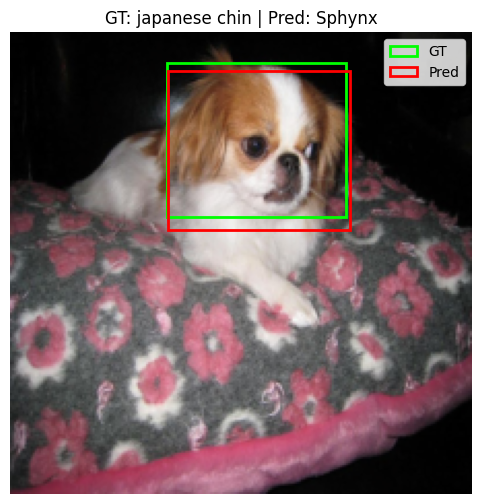

In [32]:
# Visualize a random sample: GT vs prediction
import random
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as TF

_MEAN = [0.485, 0.456, 0.406]
_STD = [0.229, 0.224, 0.225]

def _denormalize(img_tensor, mean=_MEAN, std=_STD):
    img = img_tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        img[c] = img[c] * s + m
    return img.clamp(0, 1)

def _get_class_names():
    for name in ["_ds", "ds", "train_ds"]:
        if name in globals():
            ds_obj = globals()[name]
            try:
                split = ds_obj["train"]
            except Exception:
                split = ds_obj
            try:
                return split.features["category"].names
            except Exception:
                pass
    return None

def visualize_random_prediction(model, dataset):
    idx = random.randrange(len(dataset))
    sample = dataset[idx]
    img = sample["img"]
    gt_bbox = torch.tensor(sample["bbox"], dtype=torch.float32)
    gt_label = int(sample["category"])

    if not torch.is_tensor(img):
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=_MEAN, std=_STD)

    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits, pred_bbox = model(img.unsqueeze(0).to(device))
        pred_label = int(torch.argmax(logits, dim=1).item())
        pred_bbox = pred_bbox.squeeze(0).cpu()

    gt = (gt_bbox * IMG_SIZE).tolist()
    pr = (pred_bbox * IMG_SIZE).tolist()
    gt = [min(gt[0], gt[2]), min(gt[1], gt[3]), max(gt[0], gt[2]), max(gt[1], gt[3])]
    pr = [min(pr[0], pr[2]), min(pr[1], pr[3]), max(pr[0], pr[2]), max(pr[1], pr[3])]

    img_vis = _denormalize(img).permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img_vis)
    ax.add_patch(patches.Rectangle((gt[0], gt[1]), gt[2] - gt[0], gt[3] - gt[1],
                                   linewidth=2, edgecolor='lime', facecolor='none', label='GT'))
    ax.add_patch(patches.Rectangle((pr[0], pr[1]), pr[2] - pr[0], pr[3] - pr[1],
                                   linewidth=2, edgecolor='red', facecolor='none', label='Pred'))

    class_names = _get_class_names()
    gt_name = class_names[gt_label] if class_names else str(gt_label)
    pred_name = class_names[pred_label] if class_names else str(pred_label)
    ax.set_title(f"GT: {gt_name} | Pred: {pred_name}")
    ax.axis('off')
    ax.legend()
    plt.show()
    return idx

# Usage: ensure a trained model exists
model_to_use = None
if "model" in globals():
    model_to_use = model
elif "model_v3" in globals():
    model_to_use = model_v3

dataset_to_use = test_ds if "test_ds" in globals() else valid_ds
if model_to_use is None:
    print("No trained model found. Assign your trained model to `model_to_use` and rerun this cell.")
else:
    _ = visualize_random_prediction(model_to_use, dataset_to_use)